## House Price Prediction

In [32]:
# import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
# load dataset

df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200


## check info

In [34]:
print(df.shape)
df.info()

(20640, 9)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 1.4 MB


In [35]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

## Data Cleaning

In [36]:
# fill missing values
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

# categorical column remove
df.drop('ocean_proximity', axis=1, inplace=True, errors='ignore')

## Feature Engineering

In [37]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

## Visualize Price Prediction

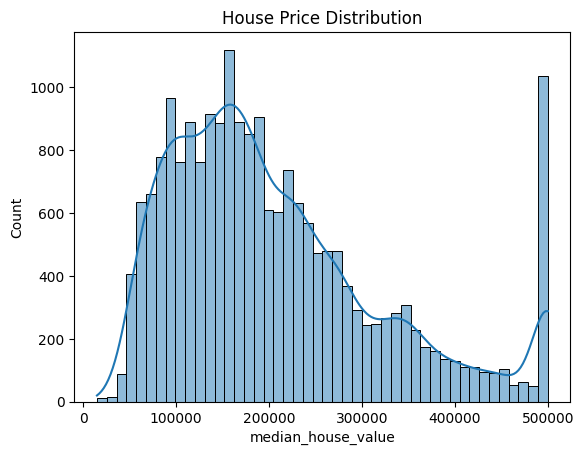

In [38]:
plt.figure()
sns.histplot(df['median_house_value'], kde=True)
plt.title("House Price Distribution")
plt.show()

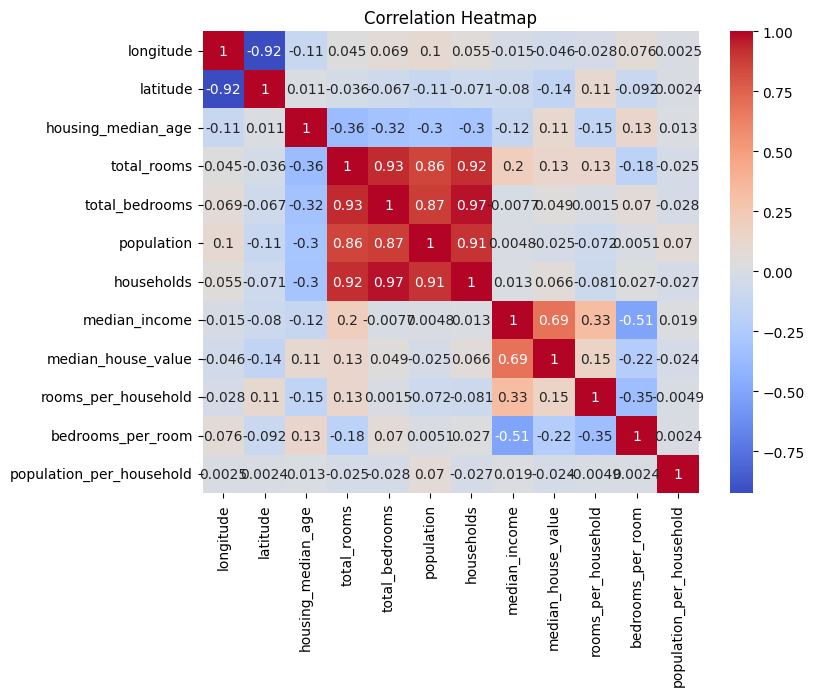

In [39]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##  Feature Selection

In [40]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

## split data

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)       

##  Define the Model

In [43]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

## Train the model

In [45]:
xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

## Evaluate the Model

In [46]:
train_pred = xgb.predict(X_train)
test_pred = xgb.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Train R2: 0.9173385500907898
Test R2: 0.828872799873352


In [48]:
# Errors
mae = mean_absolute_error(y_test, test_pred)
mse = mean_squared_error(y_test, test_pred)
rmse = np.sqrt(mse)


print(" MAE:", mae)
print(" MSE:", mse)
print(" RMSE:", rmse)

 MAE: 31246.013671875
 MSE: 2242465792.0
 RMSE: 47354.68078236828


## Cross Validation

In [ ]:
# scores = cross_val_score(xgb, scaler.fit_transform(X), y, cv=5, scoring='r2')
# # scores = cross_val_score(xgb, X, y, cv=5, scoring='r2')

# print("CV Scores:", scores)
# print("Average CV Score:", scores.mean())

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor())
])

scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')

print("Cross Validation Scores:", scores)
print("Mean R2:", scores.mean())

Cross Validation Scores: [0.54587686 0.70055282 0.73891813 0.63920379 0.62644172]
Mean R2: 0.6501986622810364


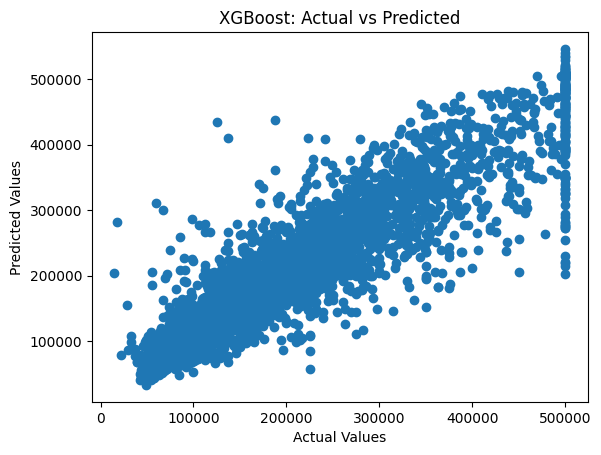

In [49]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, test_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

## Test the model on new values

In [51]:
# Example new data (same features order hona chahiye)
new_data = pd.DataFrame([{
    'longitude': -122.23,
    'latitude': 37.88,
    'housing_median_age': 41,
    'total_rooms': 880,
    'total_bedrooms': 129,
    'population': 322,
    'households': 126,
    'median_income': 8.3252
}])

# Feature engineering (IMPORTANT)
new_data['rooms_per_household'] = new_data['total_rooms'] / new_data['households']
new_data['bedrooms_per_room'] = new_data['total_bedrooms'] / new_data['total_rooms']
new_data['population_per_household'] = new_data['population'] / new_data['households']

# Same column order
new_data = new_data[X.columns]

# Scaling
new_data = scaler.transform(new_data)

# Prediction
prediction = xgb.predict(new_data)
print("Predicted Price:", prediction)

Predicted Price: [437496.56]


## Save the model

In [52]:
import joblib

joblib.dump(xgb, "house_price_model.pkl")

['house_price_model.pkl']

In [53]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']